In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import time
import json
from datetime import datetime
import os

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

num_delete = int(0.05 * len(dataset))  # 5% deletion
indices = np.random.permutation(len(dataset))

delete_idx = indices[:num_delete]
retain_idx = indices[num_delete:]

retain_set = Subset(dataset, retain_idx)
delete_set = Subset(dataset, delete_idx)

retain_loader = DataLoader(retain_set, batch_size=64, shuffle=True)
delete_loader = DataLoader(delete_set, batch_size=64, shuffle=True)


In [33]:
print(f"Total dataset size: {len(dataset)}")
print(f"Retain set size: {len(retain_set)}")
print(f"Delete set size: {len(delete_set)}")

Total dataset size: 60000
Retain set size: 57000
Delete set size: 3000


In [4]:
import matplotlib.pyplot as plt

In [5]:
def show_samples(loader, n=5):
    x, y = next(iter(loader))
    x = x.numpy()
    y = y.numpy()
    plt.figure(figsize=(12,2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(x[i][0], cmap='gray')
        plt.title(f"Label: {y[i]}")
        plt.axis('off')
    plt.show()

Some samples from the retain set:


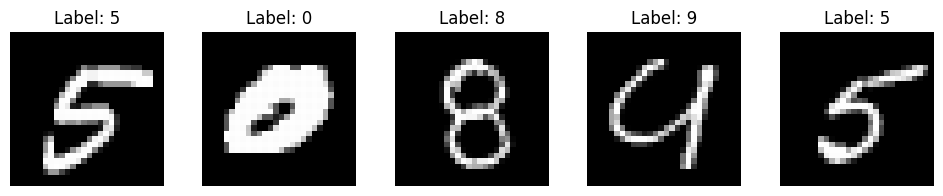

Some samples from the delete set:


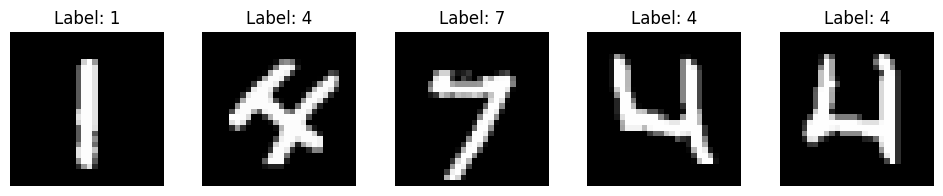

In [6]:
print("Some samples from the retain set:")
show_samples(retain_loader)

print("Some samples from the delete set:")
show_samples(delete_loader)

In [7]:
# batch shape
x_batch, y_batch = next(iter(retain_loader))
print(f"Batch X shape: {x_batch.shape}, Batch Y shape: {y_batch.shape}")

Batch X shape: torch.Size([64, 1, 28, 28]), Batch Y shape: torch.Size([64])


In [8]:
device = torch.device("cpu")

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(5408, 10)
        )

    def forward(self, x):
        return self.net(x)


In [10]:
# def train(model, loader, epochs=5):
#     optimizer = optim.Adam(model.parameters(), lr=1e-3)
#     criterion = nn.CrossEntropyLoss()
#     model.train()

#     for _ in range(epochs):
#         for x, y in loader:
#             optimizer.zero_grad()
#             loss = criterion(model(x), y)
#             loss.backward()
#             optimizer.step()

In [11]:
# device = torch.device("cpu")  
# model = SimpleCNN().to(device)
# print(model)

In [12]:
# model = SimpleCNN()
# train(model, DataLoader(dataset, batch_size=64, shuffle=True))


In [13]:
def train(model, loader, epochs=5, device=torch.device("cpu")):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(1, epochs+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # Print every 100 batches
            if (batch_idx + 1) % 100 == 0:
                print(f"Epoch [{epoch}/{epochs}], Batch [{batch_idx+1}/{len(loader)}], Loss: {loss.item():.4f}")

        # Print epoch summary
        avg_epoch_loss = running_loss / len(loader)
        print(f"--- Epoch {epoch} completed. Avg Loss: {avg_epoch_loss:.4f} ---")

In [14]:
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=5408, out_features=10, bias=True)
  )
)


In [15]:
train(model, retain_loader, epochs=1, device=device)

Epoch [1/1], Batch [100/891], Loss: 0.2096
Epoch [1/1], Batch [200/891], Loss: 0.1563
Epoch [1/1], Batch [300/891], Loss: 0.1209
Epoch [1/1], Batch [400/891], Loss: 0.0549
Epoch [1/1], Batch [500/891], Loss: 0.2339
Epoch [1/1], Batch [600/891], Loss: 0.0528
Epoch [1/1], Batch [700/891], Loss: 0.0395
Epoch [1/1], Batch [800/891], Loss: 0.0614
--- Epoch 1 completed. Avg Loss: 0.2046 ---


In [16]:
x_sample, y_sample = next(iter(retain_loader))
x_sample = x_sample.to(device)
output_sample = model(x_sample)
print("Sample output shape:", output_sample.shape)
print("Sample output (first 5):", output_sample[:5].detach())

Sample output shape: torch.Size([64, 10])
Sample output (first 5): tensor([[ -1.9641, -11.5898,  -5.7916,  -4.0185,  -0.0661,  -7.8543,  -6.5108,
           2.7124,  -3.7317,   4.7553],
        [ -3.0064, -10.5804,  -5.4196,   8.0170, -13.5324,  -0.4648, -13.4491,
          -1.8227,  -5.1147,   2.2160],
        [ -3.8958,  -6.3204,  -4.1132,  -5.6360,  -3.6717,  -5.0416,  -6.3638,
          -8.0843,   4.4035,  -1.1802],
        [ -9.1250,   0.8013,   1.4446,   2.1751,  -8.1405,  -7.4020,  -9.7490,
           5.4666,  -1.1170,  -2.5661],
        [ -0.0277,  -7.8205,  -6.5922,  -2.1090,  -7.5979,   0.5674,   6.4318,
         -10.7490,  -1.3616,  -7.0187]])


In [17]:
exact_model = SimpleCNN()
print("Training exact_model on retain set only...")

start = time.time()
train(exact_model, retain_loader)
exact_time = time.time() - start
print(f"Exact unlearning completed in {exact_time:.2f} seconds")

Training exact_model on retain set only...
Epoch [1/5], Batch [100/891], Loss: 0.2595
Epoch [1/5], Batch [200/891], Loss: 0.3359
Epoch [1/5], Batch [300/891], Loss: 0.1805
Epoch [1/5], Batch [400/891], Loss: 0.1001
Epoch [1/5], Batch [500/891], Loss: 0.0963
Epoch [1/5], Batch [600/891], Loss: 0.1329
Epoch [1/5], Batch [700/891], Loss: 0.0471
Epoch [1/5], Batch [800/891], Loss: 0.0778
--- Epoch 1 completed. Avg Loss: 0.1992 ---
Epoch [2/5], Batch [100/891], Loss: 0.0445
Epoch [2/5], Batch [200/891], Loss: 0.0231
Epoch [2/5], Batch [300/891], Loss: 0.0145
Epoch [2/5], Batch [400/891], Loss: 0.1226
Epoch [2/5], Batch [500/891], Loss: 0.0416
Epoch [2/5], Batch [600/891], Loss: 0.0466
Epoch [2/5], Batch [700/891], Loss: 0.0272
Epoch [2/5], Batch [800/891], Loss: 0.0719
--- Epoch 2 completed. Avg Loss: 0.0782 ---
Epoch [3/5], Batch [100/891], Loss: 0.0958
Epoch [3/5], Batch [200/891], Loss: 0.0989
Epoch [3/5], Batch [300/891], Loss: 0.0219
Epoch [3/5], Batch [400/891], Loss: 0.0389
Epoch [3/

Gradient-Based Unlearning

In [18]:
# Copy the trained baseline model
approx_model = SimpleCNN().to(device)
approx_model.load_state_dict(model.state_dict())  # start from baseline
print("Starting gradient-based unlearning...")

Starting gradient-based unlearning...


In [19]:
def gradient_ascent_unlearning(model, delete_loader, lr=1e-4, steps=1, device=torch.device("cpu")):
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for step in range(1, steps+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(delete_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            (-loss).backward()  # gradient ASCENT
            optimizer.step()
            running_loss += loss.item()

            # Print every 50 batches
            if (batch_idx + 1) % 50 == 0:
                print(f"Step [{step}/{steps}], Batch [{batch_idx+1}/{len(delete_loader)}], Loss: {loss.item():.4f}")

        avg_loss = running_loss / len(delete_loader)
        print(f"--- Step {step} completed. Avg Loss on deleted data: {avg_loss:.4f} ---")

In [20]:
# Copy the trained baseline model
approx_model = SimpleCNN().to(device)
approx_model.load_state_dict(model.state_dict())  # start from baseline
print("Starting gradient-based unlearning...")

# Run gradient-based unlearning
start_time = time.time()
gradient_ascent_unlearning(approx_model, delete_loader, lr=1e-4, steps=3, device=device)
approx_time = time.time() - start_time

print(f"Approximate unlearning completed in {approx_time:.2f} seconds")

Starting gradient-based unlearning...
--- Step 1 completed. Avg Loss on deleted data: 0.0960 ---
--- Step 2 completed. Avg Loss on deleted data: 0.0964 ---
--- Step 3 completed. Avg Loss on deleted data: 0.0966 ---
Approximate unlearning completed in 2.12 seconds


In [21]:
# Forgetting Metrics

def avg_loss(model, loader, device=torch.device("cpu")):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            total_loss += loss_fn(output, y).item()
    return total_loss / len(loader)

In [22]:
# Exact unlearning on deleted set
exact_deleted_loss = avg_loss(exact_model, delete_loader, device=device)
print(f"Exact model loss on deleted data: {exact_deleted_loss:.4f}")

Exact model loss on deleted data: 0.0566


In [23]:
# Approx unlearning on deleted set
approx_deleted_loss = avg_loss(approx_model, delete_loader, device=device)
print(f"Approx model loss on deleted data: {approx_deleted_loss:.4f}")

Approx model loss on deleted data: 0.0969


In [24]:
# Approx model on retained set (for comparison)
approx_retained_loss = avg_loss(approx_model, retain_loader, device=device)
print(f"Approx model loss on retained data: {approx_retained_loss:.4f}")

Approx model loss on retained data: 0.0794


In [25]:
# Quick sanity check of forgetting
print("Higher loss on deleted data means better forgetting.")
print("Compare Exact vs Approx to see trade-off between privacy and efficiency.")

Higher loss on deleted data means better forgetting.
Compare Exact vs Approx to see trade-off between privacy and efficiency.


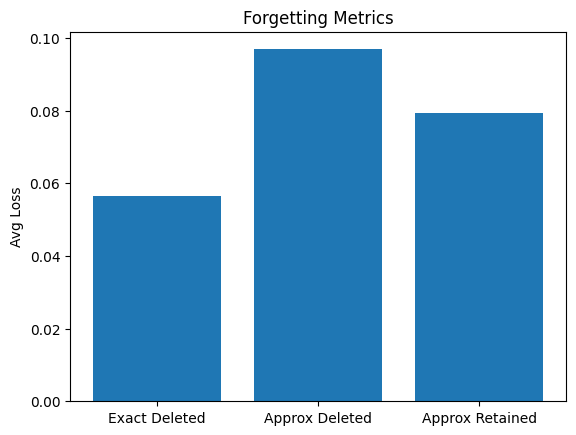

In [26]:
plt.bar(["Exact Deleted", "Approx Deleted", "Approx Retained"],
        [exact_deleted_loss, approx_deleted_loss, approx_retained_loss])
plt.ylabel("Avg Loss")
plt.title("Forgetting Metrics")
plt.show()

In [27]:
# Efficiency Metrics (Timing)
print(f"Exact unlearning time: {exact_time:.2f} seconds")
print(f"Approximate unlearning time: {approx_time:.2f} seconds")

# efficiency trade-off
efficiency_ratio = exact_time / approx_time if approx_time > 0 else float('inf')
print(f"Approx unlearning is ~{efficiency_ratio:.1f}x faster than exact unlearning")


Exact unlearning time: 65.10 seconds
Approximate unlearning time: 2.12 seconds
Approx unlearning is ~30.8x faster than exact unlearning


In [28]:
# Privacy Metric (Membership Inference – Simplified)

def confidence_score(model, loader, device=torch.device("cpu")):
    """
    Returns the average maximum softmax probability (confidence)
    Lower confidence on deleted data → better privacy
    """
    model.eval()
    scores = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            output = model(x)
            probs = torch.softmax(output, dim=1)
            # max probability per sample
            batch_conf = probs.max(dim=1).values
            scores.append(batch_conf.mean().item())
    return float(np.mean(scores))



In [29]:
# Compute confidence scores
deleted_conf = confidence_score(approx_model, delete_loader, device=device)
retained_conf = confidence_score(approx_model, retain_loader, device=device)

print(f"Deleted confidence (approx model): {deleted_conf:.4f}")
print(f"Retained confidence (approx model): {retained_conf:.4f}")
print("Smaller gap between retained & deleted confidence = better privacy")

Deleted confidence (approx model): 0.9612
Retained confidence (approx model): 0.9647
Smaller gap between retained & deleted confidence = better privacy


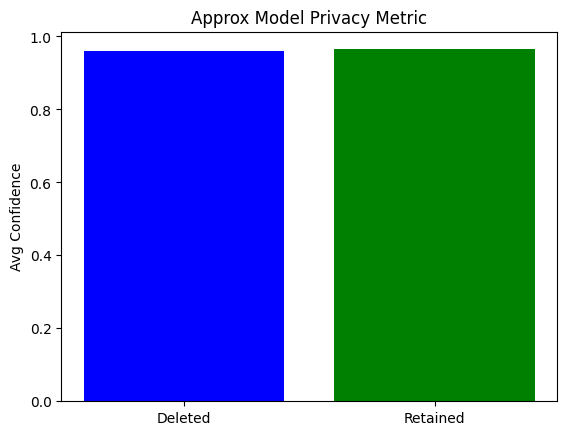

In [30]:
# for privacy
plt.bar(["Deleted", "Retained"], [deleted_conf, retained_conf], color=['blue','green'])
plt.ylabel("Avg Confidence")
plt.title("Approx Model Privacy Metric")
plt.show()

In [31]:
results = {
    "experiment_info": {
        "timestamp": datetime.now().isoformat(),
        "dataset": "MNIST",
        "model": "SimpleCNN",
        "deletion_ratio": 0.05,
        "device": "cpu",
    },

    "exact_unlearning": {
        "deleted_loss": exact_deleted_loss,
        "time_seconds": exact_time,
    },

    "approx_unlearning": {
        "method": "gradient_ascent",
        "hyperparameters": {
            "lr": 1e-4,
            "steps": 3,
            "optimizer": "SGD"
        },
        "metrics": {
            "deleted_loss": approx_deleted_loss,
            "retained_loss": approx_retained_loss,
            "deleted_confidence": deleted_conf,
            "retained_confidence": retained_conf,
        },
        "time_seconds": approx_time,
    }
}

In [32]:
# Create results directory
os.makedirs("results", exist_ok=True)

filename = f"results/unlearning_results_{int(time.time())}.json"

with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print(f"Results saved to {filename}")

Results saved to results/unlearning_results_1768718264.json
